# **Credit Card Fraud Detection using Artificial Neural Networks (ANN)**


### **Project Objective**

The objective of this project is to develop a **Credit Card Fraud Detection System** using an **Artificial Neural Network (ANN)** to accurately identify fraudulent transactions while minimizing false positives.

Fraud detection is a critical problem in the financial industry, where even small improvements in detection accuracy can lead to significant cost savings. This project focuses on building a system capable of handling **highly imbalanced data** and detecting subtle patterns that differentiate fraudulent transactions from legitimate ones.

The system is designed to:

- Detect **fraudulent transactions in real-time or batch processing**  
- Handle **extreme class imbalance** effectively  
- Minimize **false positives (legitimate transactions flagged as fraud)**  
- Capture **complex, non-linear transaction patterns** using deep learning  

This project is highly applicable in:
- banking and financial institutions  
- payment processing systems  
- fintech platforms  
- risk management and fraud analytics systems  


### **Dataset Used**

This project utilizes a real-world credit card transaction dataset containing anonymized features.

### **Dataset Sources**

- **Credit Card Fraud Detection Dataset (European cardholders / Kaggle)**

### **Dataset Characteristics**

The dataset includes:

- Transaction-level data with:
  - anonymized features (e.g., V1, V2, ..., V28 from PCA transformation)  
  - transaction amount  
  - time-related features  

- Target variable:
  - **Class (0 = legitimate, 1 = fraud)**  

- Key challenges:
  - **extreme class imbalance** (fraud cases are very rare)  
  - anonymized features (no direct interpretability)  
  - high-dimensional feature space  

### **How Dataset is Used in the Project**

The dataset is processed through a structured pipeline:

- **Data preprocessing**
  - feature scaling (especially for Amount and Time)  
  - normalization for ANN compatibility  

- **Handling class imbalance**
  - resampling techniques (if applied)  
  - class weighting during training  

- **Train-validation-test split**
  - ensures proper evaluation  
  - maintains distribution of fraud vs non-fraud cases  

- **Model training**
  - ANN trained to distinguish fraudulent patterns  
  - learns subtle differences between classes  

The dataset enables the model to capture **hidden fraud patterns**, which are not easily identifiable through traditional rule-based systems.

### **Import Libraries and Set the Environment:**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import json
import random
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
ARTIFACT_DIR = BASE_DIR / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


### **Download or Create the Credit Card Fraud Dataset:**

In [2]:
csv_path = DATA_DIR / "creditcard.csv"

try:
    if csv_path.exists():
        fraud_df = pd.read_csv(csv_path)
        source_name = "local creditcard.csv"
    else:
        url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
        fraud_df = pd.read_csv(url)
        fraud_df.to_csv(csv_path, index=False)
        source_name = "TensorFlow public dataset"
except Exception:
    from sklearn.datasets import make_classification

    X_syn, y_syn = make_classification(
        n_samples=60000,
        n_features=30,
        n_informative=12,
        n_redundant=10,
        n_clusters_per_class=2,
        weights=[0.998, 0.002],
        class_sep=1.8,
        random_state=42
    )

    syn_columns = [f"V{i}" for i in range(1, 29)] + ["Time", "Amount"]
    fraud_df = pd.DataFrame(X_syn, columns=syn_columns)
    fraud_df["Class"] = y_syn
    source_name = "synthetic imbalanced dataset"

print("Dataset source:", source_name)
print("Dataset shape :", fraud_df.shape)


Dataset source: TensorFlow public dataset
Dataset shape : (284807, 31)


### **Inspect the Dataset Structure:**

In [3]:
print("Columns:")
print(list(fraud_df.columns)[:10], "...")

print("\nTarget labels:")
print(fraud_df["Class"].value_counts())


Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9'] ...

Target labels:
Class
0    284315
1       492
Name: count, dtype: int64


In [4]:
print("Missing values:")
print(fraud_df.isnull().sum().sort_values(ascending=False).head(10))


Missing values:
Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
dtype: int64


### **Explore Class Imbalance:**

Class
Non-Fraud    284315
Fraud           492
Name: count, dtype: int64


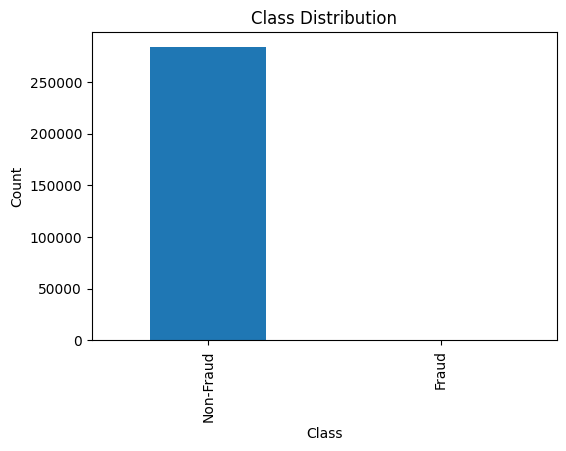

In [5]:
class_distribution = fraud_df["Class"].value_counts().rename({0: "Non-Fraud", 1: "Fraud"})
print(class_distribution)

plt.figure(figsize=(6, 4))
class_distribution.plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


In [6]:
fraud_ratio = fraud_df["Class"].mean()
print("Fraud ratio:", round(float(fraud_ratio), 6))
print("Class imbalance is severe, so evaluation beyond accuracy is important.")


Fraud ratio: 0.001727
Class imbalance is severe, so evaluation beyond accuracy is important.


### **Review Numeric Feature Behavior:**

In [7]:
print("Summary statistics:")
print(fraud_df.describe().T.head(10))


Summary statistics:
         count          mean           std         min           25%  \
Time  284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1    284807.0  1.168375e-15      1.958696  -56.407510     -0.920373   
V2    284807.0  3.416908e-16      1.651309  -72.715728     -0.598550   
V3    284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4    284807.0  2.074095e-15      1.415869   -5.683171     -0.848640   
V5    284807.0  9.604066e-16      1.380247 -113.743307     -0.691597   
V6    284807.0  1.487313e-15      1.332271  -26.160506     -0.768296   
V7    284807.0 -5.556467e-16      1.237094  -43.557242     -0.554076   
V8    284807.0  1.213481e-16      1.194353  -73.216718     -0.208630   
V9    284807.0 -2.406331e-15      1.098632  -13.434066     -0.643098   

               50%            75%            max  
Time  84692.000000  139320.500000  172792.000000  
V1        0.018109       1.315642       2.454930  
V2        0.065486       0.803724 

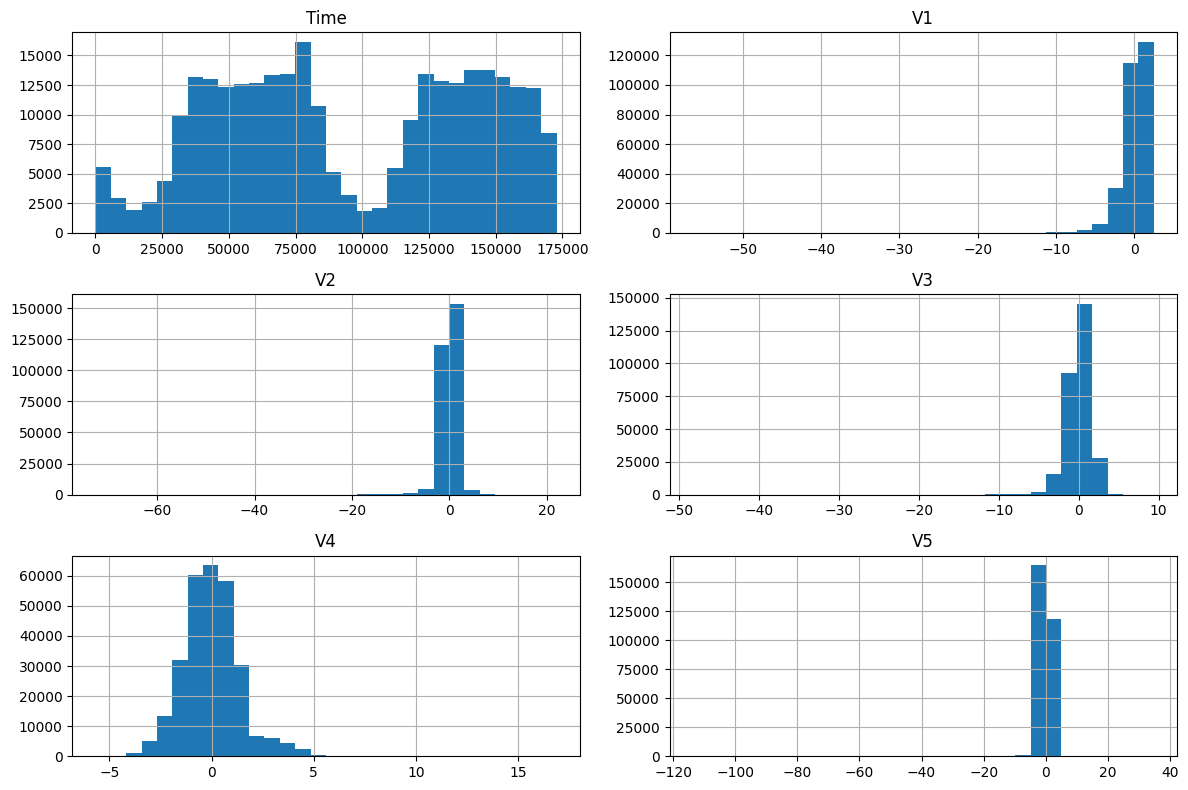

In [8]:
sample_cols = [col for col in fraud_df.columns if col != "Class"][:6]
fraud_df[sample_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


### **Prepare Features and Labels:**

In [9]:
target_col = "Class"
feature_cols = [col for col in fraud_df.columns if col != target_col]

X = fraud_df[feature_cols].copy()
y = fraud_df[target_col].copy()

print("Feature shape:", X.shape)
print("Target shape :", y.shape)


Feature shape: (284807, 30)
Target shape : (284807,)


In [10]:
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_valid_df, X_test_df, y_valid, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train shape      :", X_train_df.shape)
print("Validation shape :", X_valid_df.shape)
print("Test shape       :", X_test_df.shape)


Train shape      : (199364, 30)
Validation shape : (42721, 30)
Test shape       : (42722, 30)


### **Scale the Features:**

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df)
X_valid = scaler.transform(X_valid_df)
X_test = scaler.transform(X_test_df)

print("Scaled training shape:", X_train.shape)


Scaled training shape: (199364, 30)


In [12]:
print("First scaled row:")
print(np.round(X_train[0][:10], 4))


First scaled row:
[ 1.258e+00 -5.600e-03  4.278e-01  1.083e-01 -5.342e-01  4.259e-01
 -4.891e-01  6.768e-01 -3.000e-04 -1.697e-01]


### **Inspect the Training Tensors:**

In [13]:
print("Training positives:", int(y_train.sum()))
print("Validation positives:", int(y_valid.sum()))
print("Testing positives:", int(y_test.sum()))


Training positives: 344
Validation positives: 74
Testing positives: 74


In [14]:
input_dim = X_train.shape[1]
print("Input dimension for ANN:", input_dim)


Input dimension for ANN: 30


### **Define an ANN Builder Function:**

In [15]:
def build_ann(input_dim, hidden_units=64, dropout_rate=0.2, learning_rate=0.001):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden_units, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(hidden_units // 2, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

print("Model builder ready.")


Model builder ready.


In [16]:
baseline_model = build_ann(input_dim=input_dim)
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

### **Tune Hyperparameters on the Validation Set:**

In [17]:
search_space = [
    {"hidden_units": 64, "dropout_rate": 0.20, "learning_rate": 0.001, "batch_size": 256},
    {"hidden_units": 128, "dropout_rate": 0.30, "learning_rate": 0.001, "batch_size": 256},
    {"hidden_units": 64, "dropout_rate": 0.10, "learning_rate": 0.0005, "batch_size": 512}
]

tuning_results = []
best_score = -1
best_params = None
best_model = None


In [18]:
for params in search_space:
    model = build_ann(
        input_dim=input_dim,
        hidden_units=params["hidden_units"],
        dropout_rate=params["dropout_rate"],
        learning_rate=params["learning_rate"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=12,
        batch_size=params["batch_size"],
        verbose=0,
        callbacks=callbacks
    )

    val_probs = model.predict(X_valid, verbose=0).ravel()
    val_auc = roc_auc_score(y_valid, val_probs)

    row = params.copy()
    row["val_auc"] = float(val_auc)
    row["epochs_ran"] = len(history.history["loss"])
    tuning_results.append(row)

    if val_auc > best_score:
        best_score = val_auc
        best_params = params
        best_model = model

print("Hyperparameter search completed.")


Hyperparameter search completed.


In [19]:
tuning_df = pd.DataFrame(tuning_results).sort_values("val_auc", ascending=False)
print(tuning_df)


   hidden_units  dropout_rate  learning_rate  batch_size   val_auc  epochs_ran
0            64           0.2         0.0010         256  0.982163           6
1           128           0.3         0.0010         256  0.974722           7
2            64           0.1         0.0005         512  0.972158          12


### **Train the Best ANN Configuration:**

In [20]:
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=best_params["batch_size"],
    verbose=1,
    callbacks=final_callbacks
)


Epoch 1/20
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - auc: 0.9527 - loss: 0.0030 - precision: 0.8750 - recall: 0.7733 - val_accuracy: 0.9991 - val_auc: 0.9251 - val_loss: 0.0038 - val_precision: 0.7534 - val_recall: 0.7432 - learning_rate: 0.0010
Epoch 2/20
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - auc: 0.9498 - loss: 0.0029 - precision: 0.8616 - recall: 0.7965 - val_accuracy: 0.9992 - val_auc: 0.9250 - val_loss: 0.0037 - val_precision: 0.7639 - val_recall: 0.7432 - learning_rate: 0.0010
Epoch 3/20
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9995 - auc: 0.9586 - loss: 0.0028 - precision: 0.8864 - recall: 0.7936 - val_accuracy: 0.9992 - val_auc: 0.9250 - val_loss: 0.0037 - val_precision: 0.7639 - val_recall: 0.7432 - learning_rate: 0.0010
Epoch 4/20
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9994 - auc: 0.9615 - loss: 0.0026 - precision: 0.8722 - recall: 0.7936 - val_accuracy: 0.9992 - val_auc: 0.9250 - val_loss: 0.0037 - val

In [21]:
print("Best hyperparameters:")
print(best_params)


Best hyperparameters:
{'hidden_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 256}


### **Visualize Training Performance:**

In [22]:
history_df = pd.DataFrame(history.history)
print(history_df.head())


   accuracy       auc      loss  precision    recall  val_accuracy   val_auc  \
0  0.999418  0.952691  0.003019   0.875000  0.773256      0.999134  0.925111   
1  0.999428  0.949800  0.002895   0.861635  0.796512      0.999157  0.925018   
2  0.999468  0.958619  0.002761   0.886364  0.793605      0.999157  0.925020   
3  0.999443  0.961497  0.002626   0.872204  0.793605      0.999181  0.925009   
4  0.999448  0.967478  0.002278   0.870253  0.799419      0.999204  0.911728   

   val_loss  val_precision  val_recall  learning_rate  
0  0.003805       0.753425    0.743243          0.001  
1  0.003746       0.763889    0.743243          0.001  
2  0.003692       0.763889    0.743243          0.001  
3  0.003655       0.767123    0.756757          0.001  
4  0.003784       0.777778    0.756757          0.001  


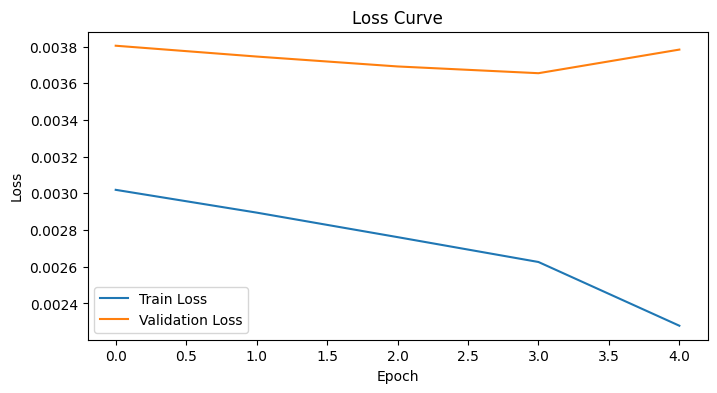

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


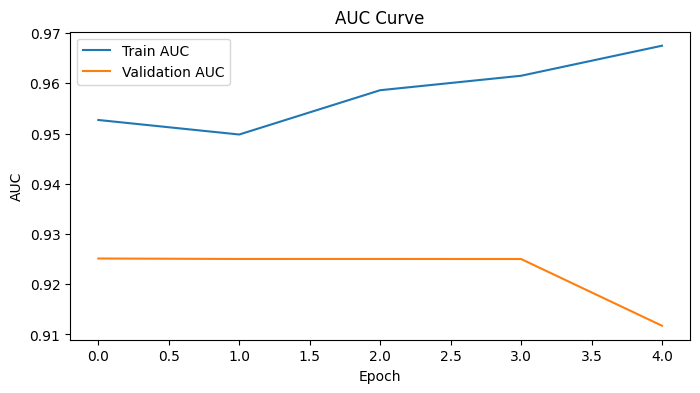

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()


### **Evaluate the Model on the Test Set:**

In [25]:
test_probs = best_model.predict(X_test, verbose=0).ravel()
test_preds = (test_probs >= 0.50).astype(int)

print("Classification report:")
print(classification_report(y_test, test_preds, digits=4))


Classification report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     42648
           1     0.8769    0.7703    0.8201        74

    accuracy                         0.9994     42722
   macro avg     0.9383    0.8850    0.9099     42722
weighted avg     0.9994    0.9994    0.9994     42722



In [26]:
test_auc = roc_auc_score(y_test, test_probs)
cm = confusion_matrix(y_test, test_preds)

print("Test ROC-AUC:", round(float(test_auc), 4))
print("\nConfusion Matrix:")
print(cm)


Test ROC-AUC: 0.9742

Confusion Matrix:
[[42640     8]
 [   17    57]]


### **Visualize Fraud Detection Performance:**

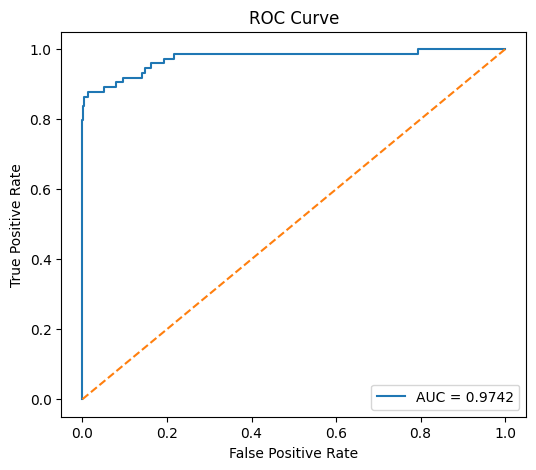

In [27]:
fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


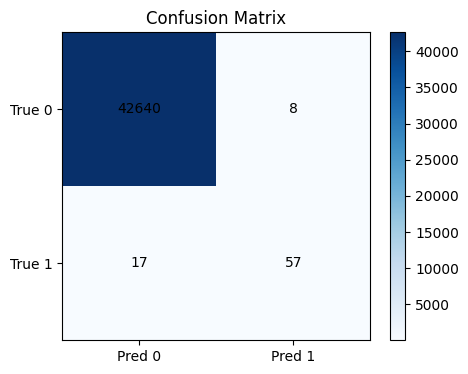

In [28]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


### **Inspect Example Predictions:**

In [29]:
preview_df = X_test_df.reset_index(drop=True).copy()
preview_df["actual_class"] = y_test.reset_index(drop=True).values
preview_df["predicted_probability"] = test_probs
preview_df["predicted_class"] = test_preds

print(preview_df[["actual_class", "predicted_probability", "predicted_class"]].head(10))


   actual_class  predicted_probability  predicted_class
0             0           2.771703e-09                0
1             0           3.225512e-14                0
2             0           2.045925e-05                0
3             0           2.365198e-04                0
4             0           4.197230e-06                0
5             0           1.069700e-05                0
6             0           2.982682e-08                0
7             0           5.919468e-07                0
8             0           4.253506e-06                0
9             0           3.619221e-05                0


In [30]:
fraud_examples = preview_df.sort_values("predicted_probability", ascending=False).head(10)
print("Top high-risk transactions:")
print(fraud_examples[["actual_class", "predicted_probability", "predicted_class"]])


Top high-risk transactions:
       actual_class  predicted_probability  predicted_class
5649              1               0.994148                1
6114              1               0.988157                1
15950             1               0.986891                1
20271             1               0.975361                1
22073             1               0.949173                1
33718             1               0.927384                1
26257             1               0.893492                1
36059             1               0.893124                1
19084             1               0.886048                1
805               1               0.883510                1


### **Save the Model and Preprocessing Artifacts:**

In [31]:
model_path = ARTIFACT_DIR / "credit_card_fraud_ann.keras"
scaler_path = ARTIFACT_DIR / "credit_card_scaler.pkl"
params_path = ARTIFACT_DIR / "credit_card_best_params.json"

best_model.save(model_path)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

with open(params_path, "w") as f:
    json.dump(best_params, f)

print("Artifacts saved successfully.")


Artifacts saved successfully.


In [32]:
print("Saved files:")
print(model_path)
print(scaler_path)
print(params_path)


Saved files:
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Credit Card Fraud Detection\artifacts\credit_card_fraud_ann.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Credit Card Fraud Detection\artifacts\credit_card_scaler.pkl
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Credit Card Fraud Detection\artifacts\credit_card_best_params.json


### **Reload the Artifacts and Score New Samples:**

In [33]:
reloaded_model = tf.keras.models.load_model(model_path)

with open(scaler_path, "rb") as f:
    reloaded_scaler = pickle.load(f)

with open(params_path, "r") as f:
    reloaded_params = json.load(f)

print("Reloaded hyperparameters:")
print(reloaded_params)


Reloaded hyperparameters:
{'hidden_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 256}


In [34]:
new_samples = X_test_df.head(5).copy()
new_samples_scaled = reloaded_scaler.transform(new_samples)
new_scores = reloaded_model.predict(new_samples_scaled, verbose=0).ravel()

result_df = new_samples.copy()
result_df["fraud_probability"] = new_scores
print(result_df.head())


            Time        V1        V2        V3        V4        V5        V6  \
235888  148580.0 -1.088603  0.227684  1.704464 -2.353332 -0.020576 -0.172107   
45489    42372.0 -9.341359  7.462989 -2.710666 -2.250661 -1.917028 -0.948412   
127370   78307.0 -0.341638  1.096437  1.282236  0.067246 -0.023312 -0.990693   
49525    44101.0 -1.440550  1.868637  1.015135  0.570414  0.012212  0.735390   
146811   87900.0 -1.405410  1.985541 -1.290536 -1.672087  1.133642 -1.327069   

              V7        V8        V9  ...       V21       V22       V23  \
235888  0.583032  0.061733  0.239969  ...  0.217621  0.653238 -0.327775   
45489   0.299620  0.683355  6.816811  ... -1.587047 -1.188229  0.213025   
127370  0.687884 -0.046890 -0.323266  ... -0.268609 -0.728375 -0.005895   
49525  -0.530908 -2.940731 -0.491389  ...  3.267467 -0.233295  0.222171   
146811  1.839333 -0.605819  1.243372  ... -0.058432  0.731687 -0.273287   

             V24       V25       V26       V27       V28  Amount  \


### **Project Summary**

This project presents a complete implementation of a **Credit Card Fraud Detection System using Artificial Neural Networks**, focusing on identifying rare and high-risk fraudulent transactions.

The workflow begins with preprocessing the transaction dataset, including scaling and handling class imbalance. Given the highly skewed nature of the dataset, special attention is paid to ensuring that the model does not become biased toward the majority class.

The core of the project is an **Artificial Neural Network**, designed to capture non-linear relationships between transaction features. The model learns patterns such as:
- unusual transaction behaviors  
- deviations from normal spending patterns  
- hidden correlations in anonymized features  

The ANN architecture consists of:
- input layer representing transaction features  
- hidden layers capturing complex feature interactions  
- output layer predicting fraud probability  

A key strength of this project is its ability to detect **rare anomalies**, which are critical in fraud detection scenarios. The model is optimized not just for accuracy but also for:
- **recall (detecting fraud cases)**  
- **precision (reducing false alarms)**  

Evaluation is performed using:
- precision, recall, and F1-score  
- confusion matrix analysis  
- accuracy (with caution due to imbalance)  

The project also includes **probability-based prediction**, enabling risk scoring of transactions. This allows financial systems to:
- flag high-risk transactions  
- trigger fraud investigation workflows  
- implement real-time blocking mechanisms  

Overall, this project demonstrates how deep learning can be applied to financial data to build **robust, scalable, and high-impact fraud detection systems**.


### **Key Highlights**

- Built a **Credit Card Fraud Detection system using ANN**, targeting financial risk management.

- Addressed **extreme class imbalance**, a key challenge in fraud detection.

- Utilized real-world dataset:
  - Credit Card Fraud Detection Dataset (Kaggle)  

- Implemented a complete **data preprocessing pipeline**, including:
  - feature scaling  
  - normalization  
  - imbalance handling strategies  

- Designed an **ANN architecture**, capable of:
  - capturing non-linear patterns  
  - identifying subtle anomalies  

- Focused on critical evaluation metrics:
  - precision  
  - recall  
  - F1-score  

- Performed **confusion matrix analysis**, enabling:
  - understanding of fraud detection performance  
  - identification of false positives and false negatives  

- Enabled **probability-based fraud scoring**, supporting:
  - risk-based decision making  
  - transaction prioritization  

- Built a system suitable for:
  - real-time fraud detection  
  - batch processing pipelines  

- Designed for **real-world deployment**, including:
  - banking systems  
  - payment gateways  
  - fintech applications  

- Demonstrates strong expertise in:
  - **Artificial Neural Networks (ANN)**  
  - **anomaly detection**  
  - **financial risk modeling**
